In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT
from model import SSLModel
from data_split import create_train_val_split
from extract_XLSR_feature import extract_features_from_csv
from visualization import plot_training_curves
from dataset import create_dataloaders
from train import train
import numpy as np

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "Pitt"

In [3]:
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}"
XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"{DATASET_NAME}_xlsr_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using mps


## Step 1: Train/Validation Set Split

In [5]:
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir = RAW_AUDIO_DIR,
    train_csv_path = TRAIN_CSV,
    val_csv_path = VAL_CSV,
    feature_dir_name = FEATURE_DIR_NAME,
    dataset_name = DATASET_NAME,
    xlsr=True
)

============= Pitt Train(80.0%) and Val(20%) Split Complete! =============
Training set: 440 samples (Control: 193, Dementia: 247)
Validation set: 111 samples (Control: 49, Dementia: 62)


## Step 2: Extract XLSR Features

In [6]:
ssl_model = SSLModel(device, freeze_xlsr=True)

extract_features_from_csv(
    csv_path=TRAIN_CSV,
    split_name="Train Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)

extract_features_from_csv(
    csv_path=VAL_CSV,
    split_name="Val Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


XLSR:Using original XLSR model


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



============= Extracting XLSR features for Train Set =============
440 Audio Files


Extracting Train Set: 100%|██████████| 440/440 [00:00<00:00, 67452.26it/s]


Successfully extracted: 0
Already exists (skipped): 440
Errors: 0
Total: 440

============= Extracting XLSR features for Val Set =============
111 Audio Files


Extracting Val Set: 100%|██████████| 111/111 [00:00<00:00, 52827.38it/s]

Successfully extracted: 0
Already exists (skipped): 111
Errors: 0
Total: 111


(0, 111, 111)

## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=True)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 111 samples
Control: 49, Dementia: 62




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Seed 21: Val Acc=68.47%, Control Acc=57.14%, Dementia Acc=77.42%, F1=0.7328, Val Loss=0.7186


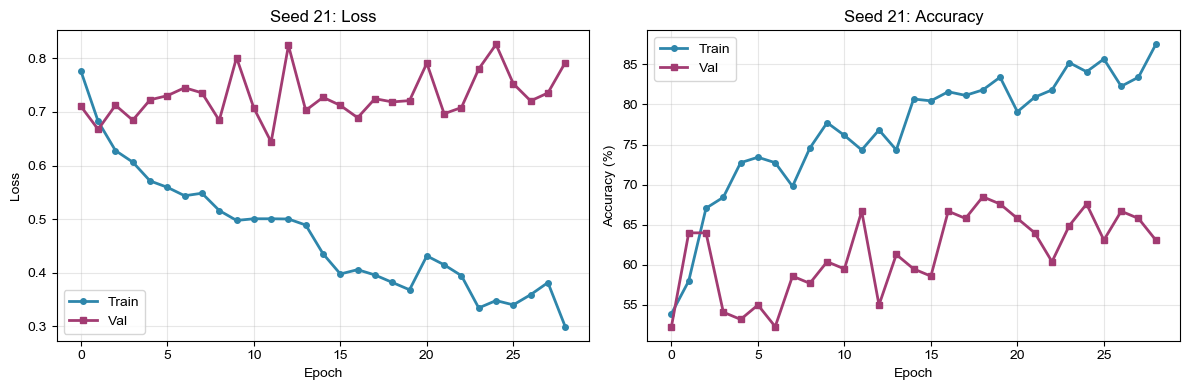

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42: Val Acc=67.57%, Control Acc=55.10%, Dementia Acc=77.42%, F1=0.7273, Val Loss=0.6219


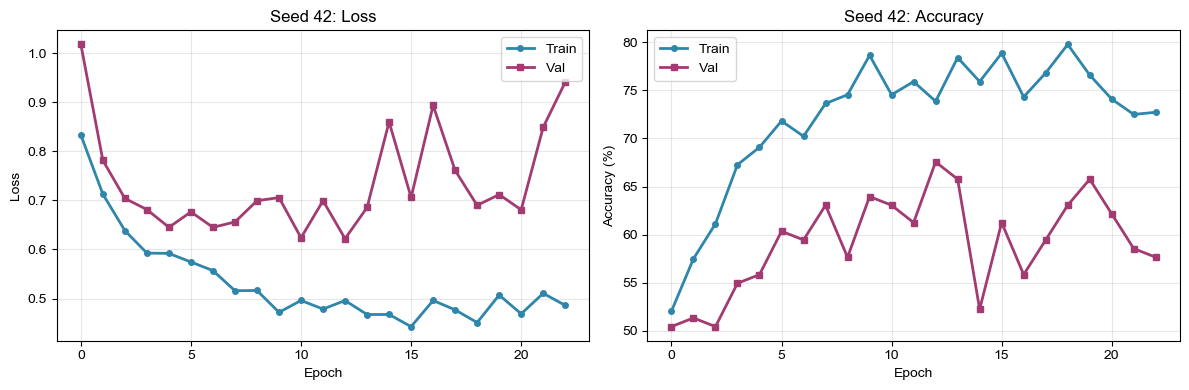

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84: Val Acc=64.86%, Control Acc=44.90%, Dementia Acc=80.65%, F1=0.7194, Val Loss=0.7219


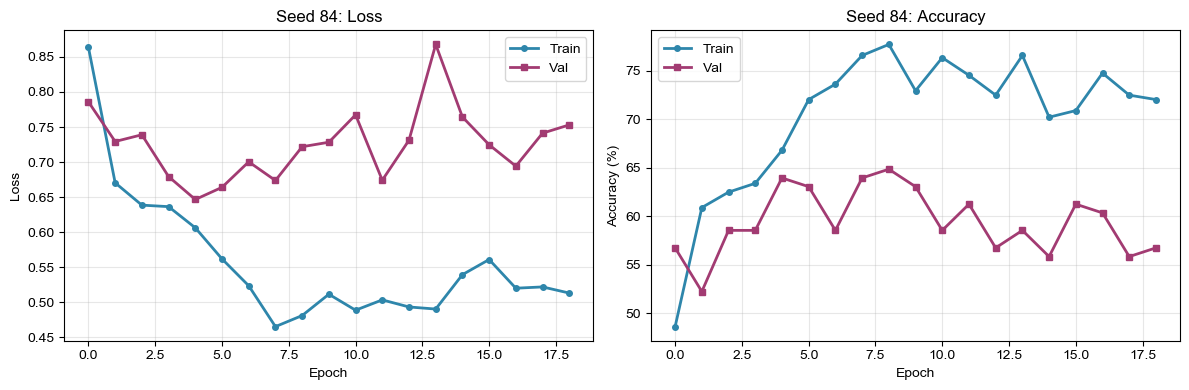

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168: Val Acc=67.57%, Control Acc=53.06%, Dementia Acc=79.03%, F1=0.7313, Val Loss=0.6323


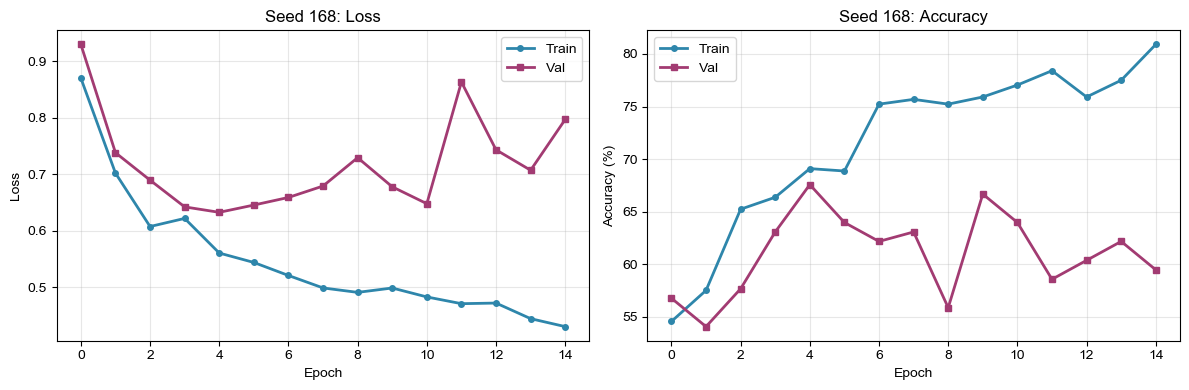

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336: Val Acc=64.86%, Control Acc=44.90%, Dementia Acc=80.65%, F1=0.7194, Val Loss=0.7420


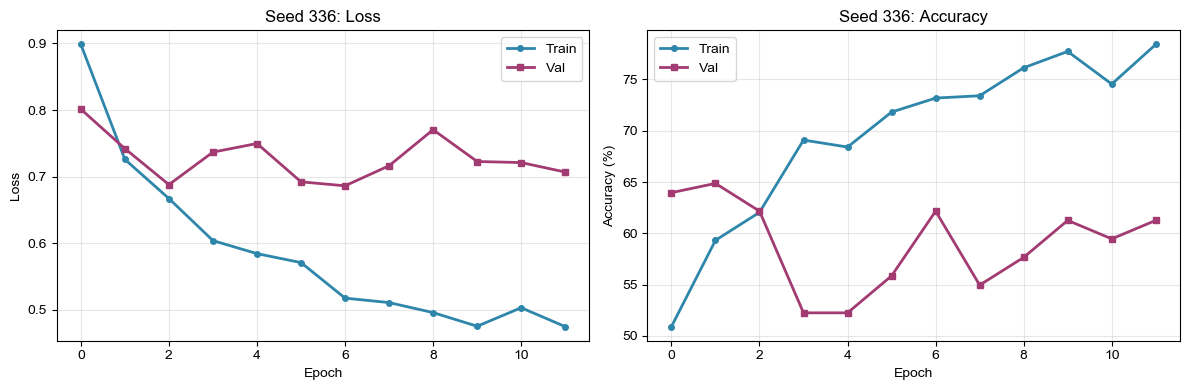

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = [score*100 for score in all_results['f1_scores']]

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)
mean_control_acc = np.mean(control_accs)
mean_dementia_acc = np.mean(dementia_accs)
mean_f1 = np.mean(f1_scores)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.2f}%")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.2f}%")


Mean Validation Accuracy: 66.67%
Mean Validation Loss: 0.6874
Mean Control Accuracy: 51.02%
Mean Dementia Accuracy: 79.03%
Mean F1 Score: 72.61%

Detailed Results:
Seed 21: Acc=68.47%, Loss=0.7186, Control Acc=57.14%, Dementia Acc=77.42%, F1=73.28%
Seed 42: Acc=67.57%, Loss=0.6219, Control Acc=55.10%, Dementia Acc=77.42%, F1=72.73%
Seed 84: Acc=64.86%, Loss=0.7219, Control Acc=44.90%, Dementia Acc=80.65%, F1=71.94%
Seed 168: Acc=67.57%, Loss=0.6323, Control Acc=53.06%, Dementia Acc=79.03%, F1=73.13%
Seed 336: Acc=64.86%, Loss=0.7420, Control Acc=44.90%, Dementia Acc=80.65%, F1=71.94%
